# 🟩 Phase 2 — Dashboard: Fees Over Time
## Bitcoin On-Chain Analytics (2017-2026)
## Analysis Period: Binance Era (Jul 2017 – Present)

**Objective:** Analyze BTC fee evolution during the modern exchange era.

- Daily total fees since Binance launch (July 14, 2017)
- 7-day and 30-day moving averages
- Halving events (2020, 2024)
- Static matplotlib visualizations

In [1]:
import os
import clickhouse_connect
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

os.makedirs('images', exist_ok=True)

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12, 'figure.dpi': 100})

print('📦 Libraries loaded successfully')

📦 Libraries loaded successfully


In [2]:
# Connect to ClickHouse
client = clickhouse_connect.get_client(
    host='localhost',
    port=8123,
    username='default',
    password='',
    database='default'
)
print('✅ Connected to ClickHouse')

# Binance Era: July 14, 2017
BINANCE_LAUNCH = '2017-07-14'

# Daily fees query — Binance Era only
print(f'🚀 Running daily fees query from {BINANCE_LAUNCH}...')

df_fees = client.query_df(f'''
    SELECT 
        toDate(toDateTime(time)) AS date,
        sum(fees_sats) / 100000000.0 AS fees_btc,
        count() AS num_blocks
    FROM block_metrics
    WHERE toDate(toDateTime(time)) >= '{BINANCE_LAUNCH}'
    GROUP BY date
    ORDER BY date
''')

total_fees = df_fees['fees_btc'].sum()
print(f'✅ Query complete: {len(df_fees):,} days')
print(f'   Period: {df_fees["date"].min()} → {df_fees["date"].max()}')
print(f'   Total fees: {total_fees:,.0f} BTC')
df_fees.head()

✅ Connected to ClickHouse
🚀 Running daily fees query from 2017-07-14...
✅ Query complete: 3,218 days
   Period: 2017-07-14 00:00:00 → 2026-05-05 00:00:00
   Total fees: 192,552 BTC


,date,fees_btc,num_blocks
0,2017-07-14,264.115056,131
1,2017-07-15,322.664401,141
2,2017-07-16,163.337466,149
3,2017-07-17,205.070988,156
4,2017-07-18,222.762264,154


In [3]:
# Calculate moving averages
df_fees['MA7'] = df_fees['fees_btc'].rolling(window=7, center=True).mean()
df_fees['MA30'] = df_fees['fees_btc'].rolling(window=30, center=True).mean()

# Quick stats
print('📊 Daily fees statistics — Binance Era (BTC):')
print(f'  Period:           {df_fees["date"].min()} → {df_fees["date"].max()}')
print(f'  Days:             {len(df_fees):,}')
print(f'  Mean:             {df_fees["fees_btc"].mean():.2f} BTC')
print(f'  Median:           {df_fees["fees_btc"].median():.2f} BTC')
print(f'  Max:              {df_fees["fees_btc"].max():.2f} BTC')
idx_max = df_fees["fees_btc"].idxmax()
print(f'  Max date:         {df_fees.loc[idx_max, "date"].strftime("%d %b %Y")}')
print(f'  Cumulative:       {df_fees["fees_btc"].sum():,.0f} BTC')

📊 Daily fees statistics — Binance Era (BTC):
  Period:           2017-07-14 00:00:00 → 2026-05-05 00:00:00
  Days:             3,218
  Mean:             59.84 BTC
  Median:           23.04 BTC
  Max:              1369.48 BTC
  Max date:         22 Dec 2017
  Cumulative:       192,552 BTC


✅ Saved: images/fees_over_time_binance_era.png


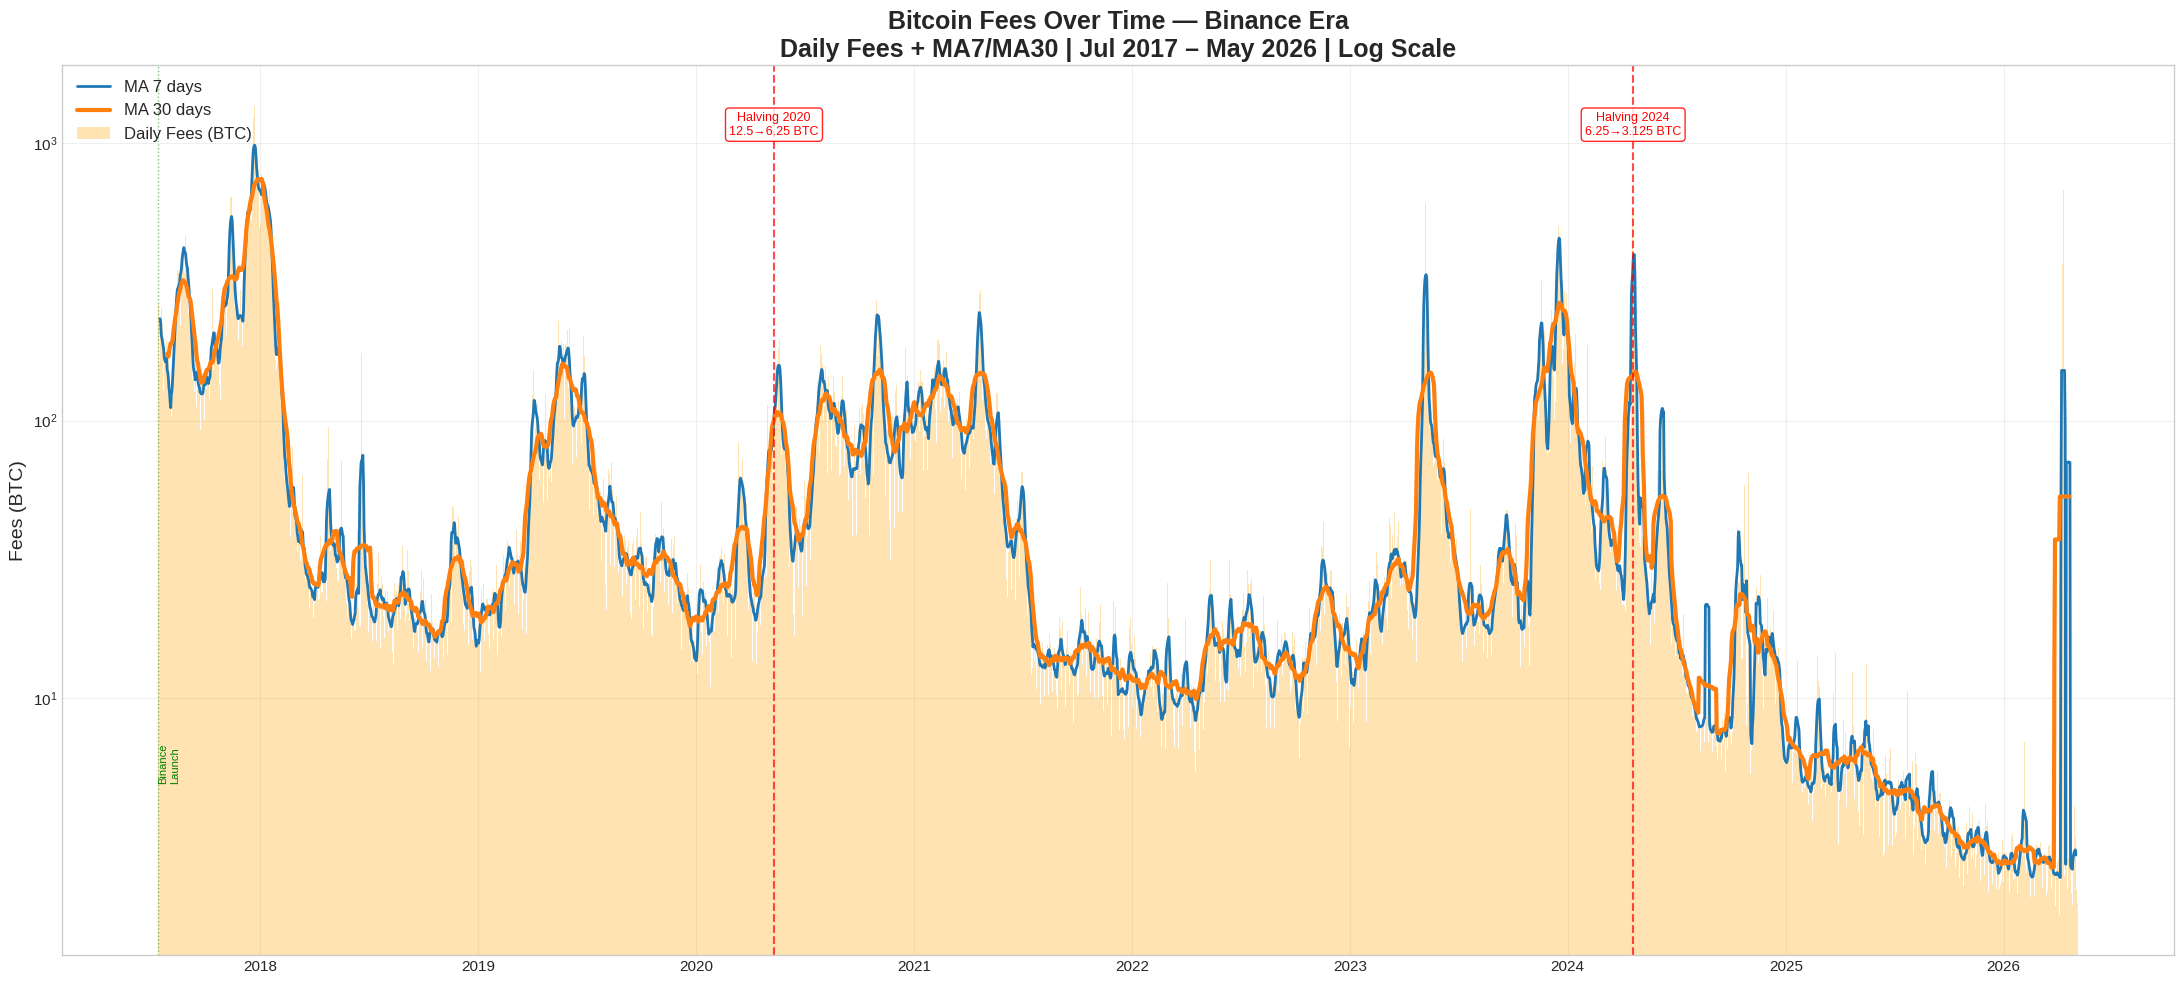

In [4]:
# Chart 1: Full Binance Era — Log Scale
fig, ax = plt.subplots(figsize=(22, 10))

# Daily fees bars
ax.bar(df_fees['date'], df_fees['fees_btc'], color='orange', alpha=0.3, width=1, label='Daily Fees (BTC)')

# Moving averages
ax.plot(df_fees['date'], df_fees['MA7'], color='#1f77b4', linewidth=2, label='MA 7 days')
ax.plot(df_fees['date'], df_fees['MA30'], color='#ff7f0e', linewidth=3, label='MA 30 days')

# Halving lines
halvings = [
    ('2020-05-11', 'Halving 2020\n12.5→6.25 BTC'),
    ('2024-04-20', 'Halving 2024\n6.25→3.125 BTC'),
]
for date_str, label in halvings:
    d = pd.to_datetime(date_str)
    ax.axvline(x=d, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    ax.text(d, df_fees['fees_btc'].max() * 0.95, label,
            color='red', fontsize=9, ha='center', va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85, edgecolor='red'))

# Binance launch line
ax.axvline(x=pd.to_datetime('2017-07-14'), color='green', linestyle=':', linewidth=1, alpha=0.5)
ax.text(pd.to_datetime('2017-07-14'), df_fees['fees_btc'].min() * 3, 'Binance\nLaunch',
        color='green', fontsize=8, ha='left', rotation=90)

# Formatting
ax.set_yscale('log')
ax.set_ylabel('Fees (BTC)', fontsize=14)
ax.set_title('Bitcoin Fees Over Time — Binance Era\nDaily Fees + MA7/MA30 | Jul 2017 – May 2026 | Log Scale',
             fontsize=18, fontweight='bold')
ax.legend(loc='upper left', fontsize=12)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.tick_params(axis='both', labelsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('images/fees_over_time_binance_era.png', dpi=300, bbox_inches='tight')
print('✅ Saved: images/fees_over_time_binance_era.png')
plt.show()

✅ Saved: images/fees_binance_era_linear.png


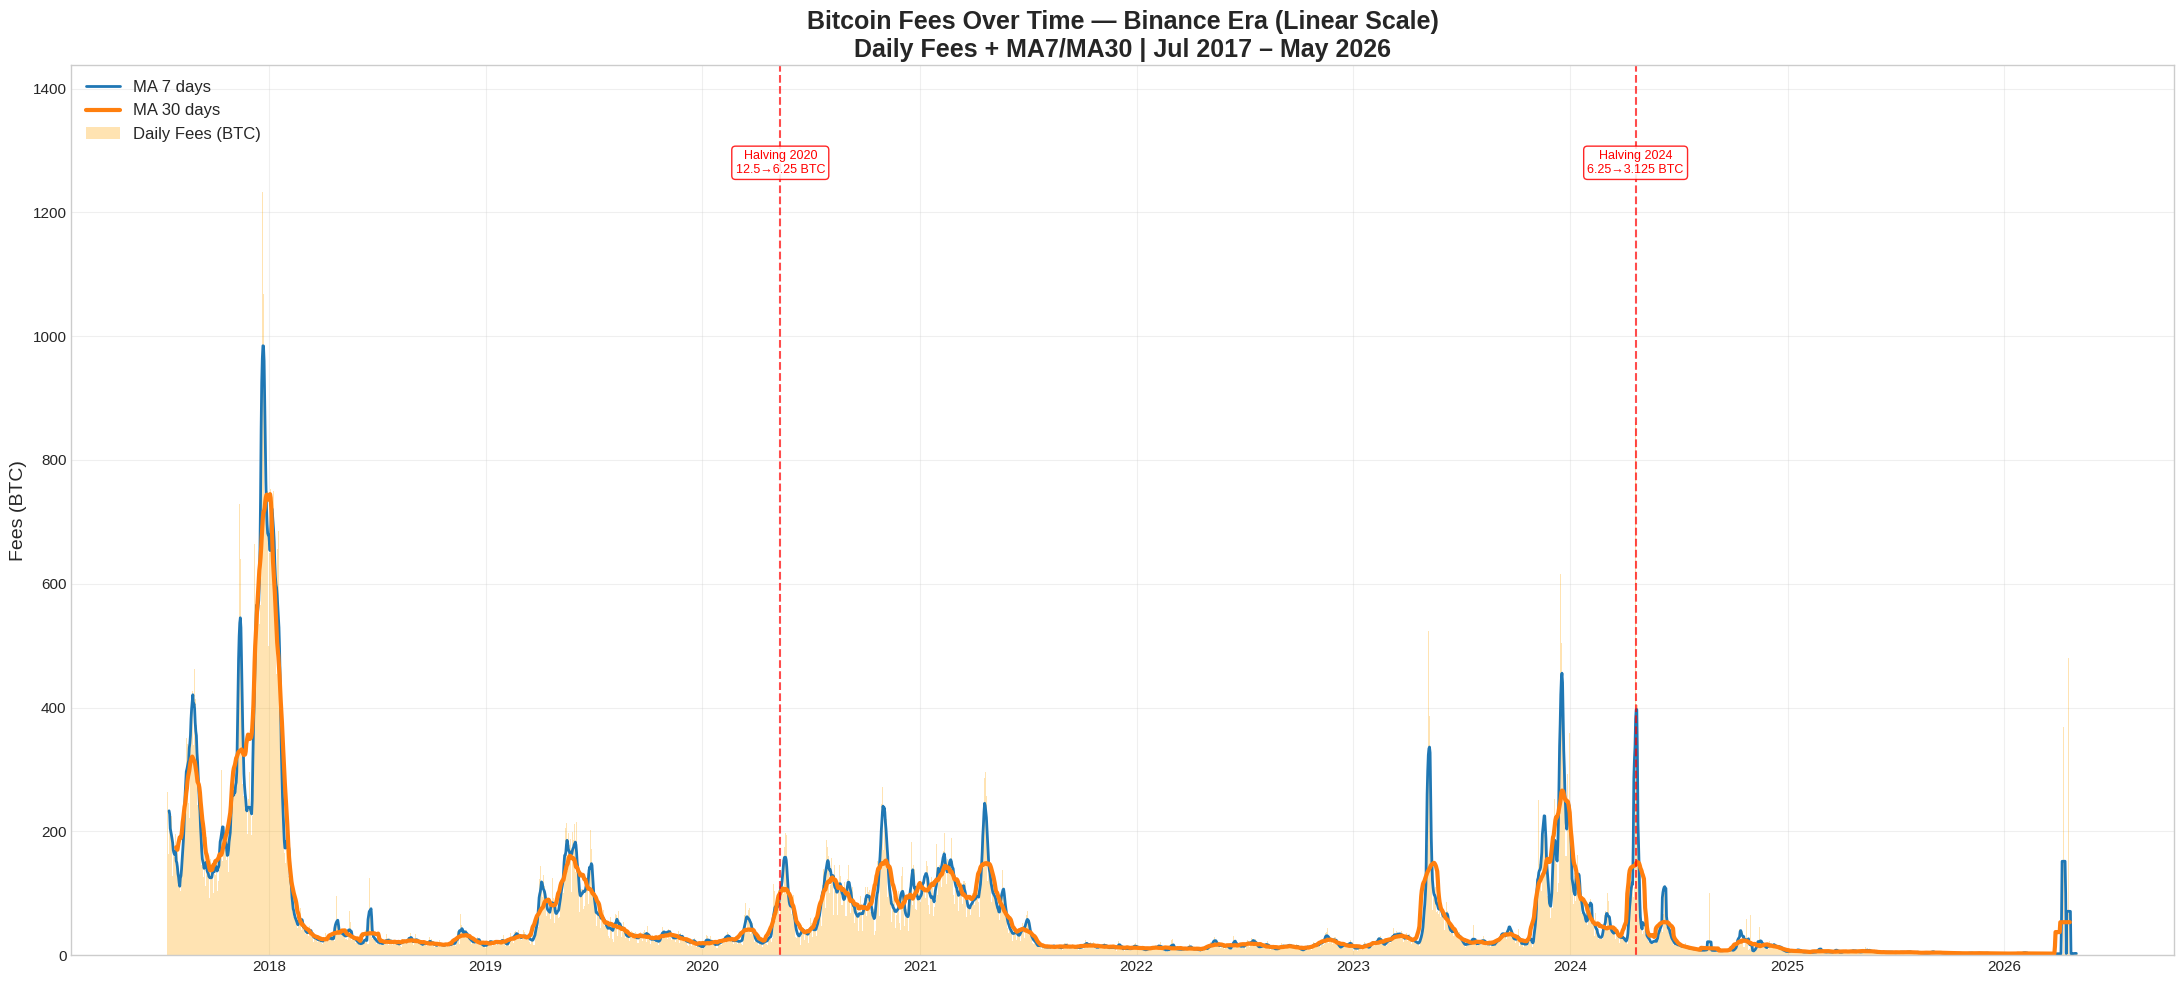

In [5]:
# Chart 2: Full Binance Era — Linear Scale
fig, ax = plt.subplots(figsize=(22, 10))

# Daily fees bars
ax.bar(df_fees['date'], df_fees['fees_btc'], color='orange', alpha=0.3, width=1, label='Daily Fees (BTC)')

# Moving averages
ax.plot(df_fees['date'], df_fees['MA7'], color='#1f77b4', linewidth=2, label='MA 7 days')
ax.plot(df_fees['date'], df_fees['MA30'], color='#ff7f0e', linewidth=3, label='MA 30 days')

# Halving lines
for date_str, label in halvings:
    d = pd.to_datetime(date_str)
    ax.axvline(x=d, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    ax.text(d, df_fees['fees_btc'].max() * 0.95, label,
            color='red', fontsize=9, ha='center', va='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.85, edgecolor='red'))

# Formatting
ax.set_ylabel('Fees (BTC)', fontsize=14)
ax.set_title('Bitcoin Fees Over Time — Binance Era (Linear Scale)\nDaily Fees + MA7/MA30 | Jul 2017 – May 2026',
             fontsize=18, fontweight='bold')
ax.legend(loc='upper left', fontsize=12)
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.tick_params(axis='both', labelsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('images/fees_binance_era_linear.png', dpi=300, bbox_inches='tight')
print('✅ Saved: images/fees_binance_era_linear.png')
plt.show()

✅ Saved: images/fees_last_2_years_binance_era.png


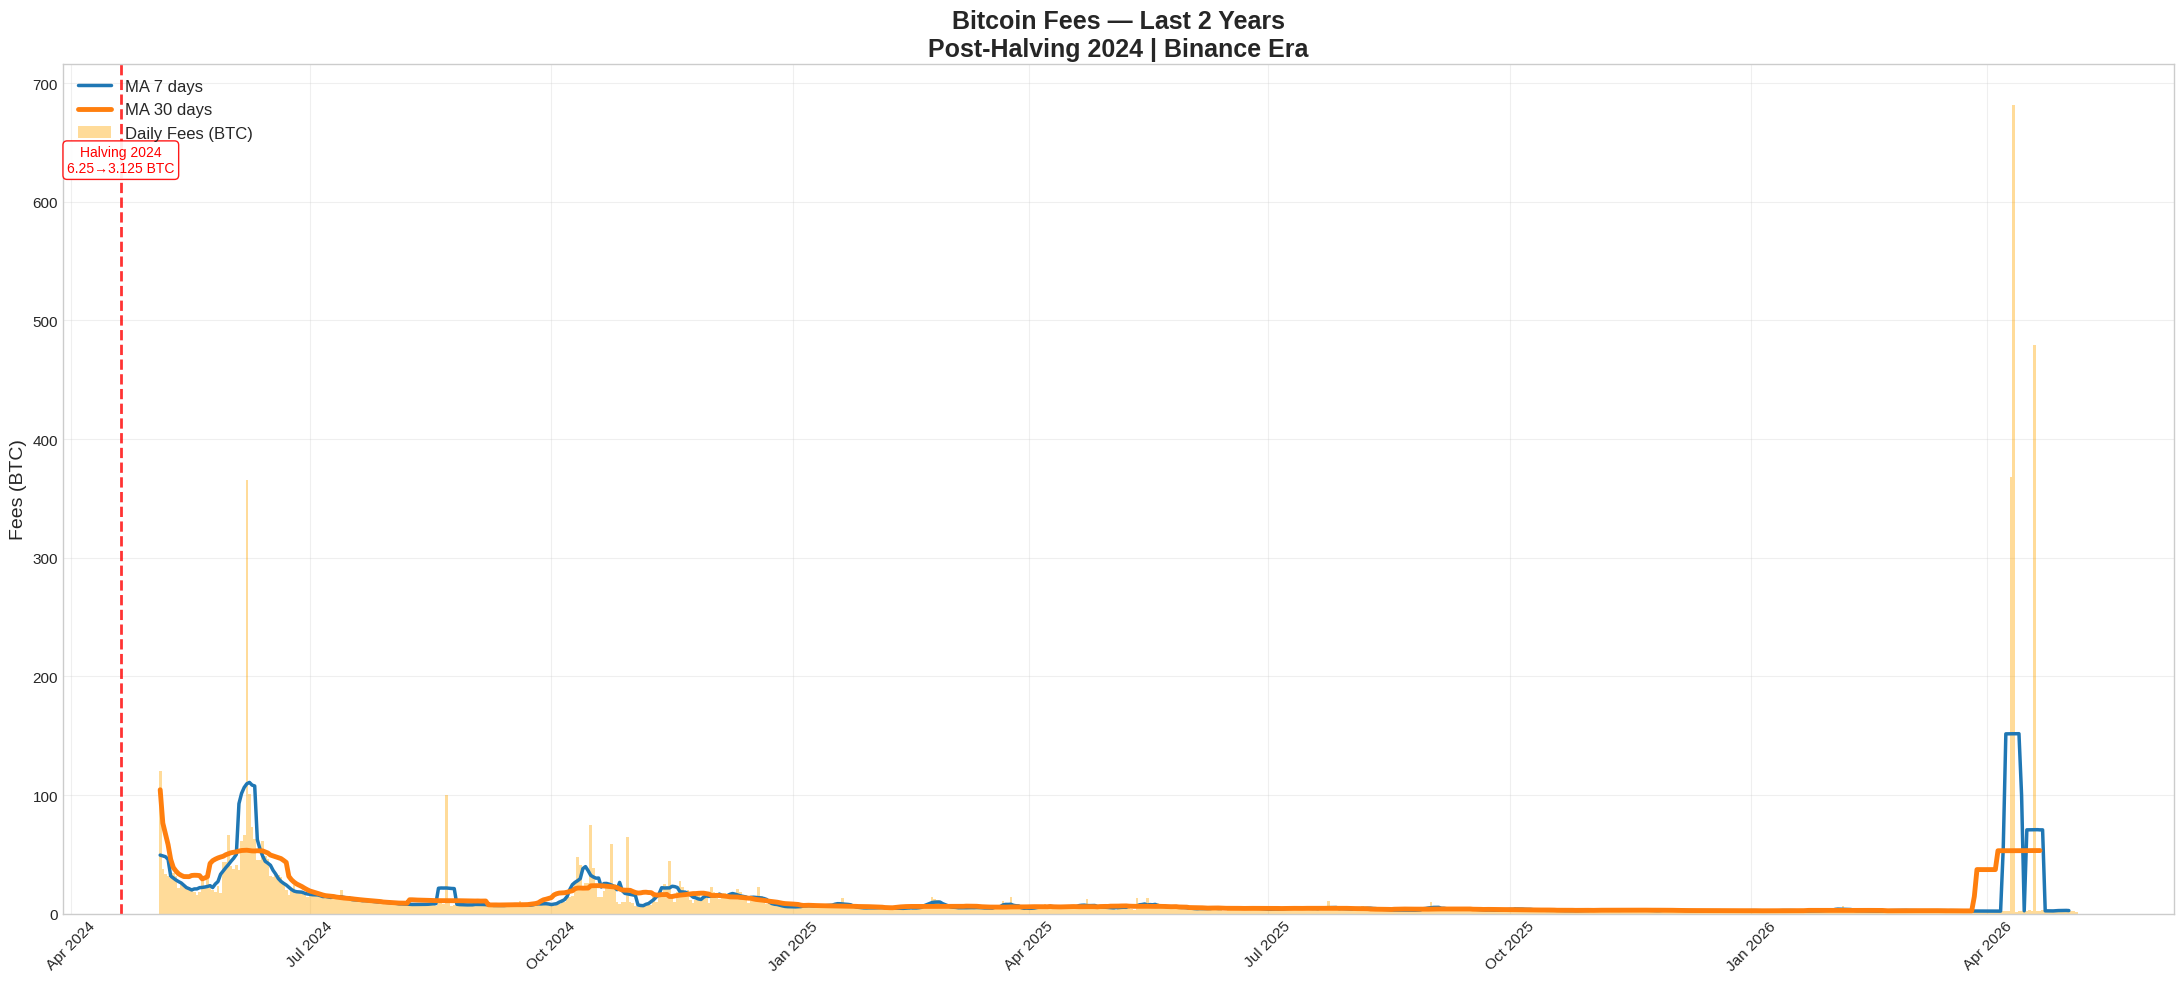

In [6]:
# Chart 3: Zoom — Last 2 Years
last_date = df_fees['date'].max()
two_years_ago = last_date - pd.DateOffset(years=2)
df_recent = df_fees[df_fees['date'] >= two_years_ago]

fig, ax = plt.subplots(figsize=(22, 10))

# Daily fees bars
ax.bar(df_recent['date'], df_recent['fees_btc'], color='orange', alpha=0.4, width=1, label='Daily Fees (BTC)')

# Moving averages
ax.plot(df_recent['date'], df_recent['MA7'], color='#1f77b4', linewidth=2.5, label='MA 7 days')
ax.plot(df_recent['date'], df_recent['MA30'], color='#ff7f0e', linewidth=3.5, label='MA 30 days')

# Halving 2024
d = pd.to_datetime('2024-04-20')
ax.axvline(x=d, color='red', linestyle='--', linewidth=2, alpha=0.8)
ax.text(d, df_recent['fees_btc'].max() * 0.95, 'Halving 2024\n6.25→3.125 BTC',
        color='red', fontsize=10, ha='center', va='top',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9, edgecolor='red'))

# Formatting
ax.set_ylabel('Fees (BTC)', fontsize=14)
ax.set_title('Bitcoin Fees — Last 2 Years\nPost-Halving 2024 | Binance Era',
             fontsize=18, fontweight='bold')
ax.legend(loc='upper left', fontsize=12)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
ax.tick_params(axis='both', labelsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('images/fees_last_2_years_binance_era.png', dpi=300, bbox_inches='tight')
print('✅ Saved: images/fees_last_2_years_binance_era.png')
plt.show()

In [7]:
# Top 10 days by fees (Binance Era)
df_top10 = df_fees.nlargest(10, 'fees_btc')[['date', 'fees_btc', 'num_blocks']]
df_top10['fees_btc'] = df_top10['fees_btc'].round(2)
print('🔝 Top 10 days by fees — Binance Era:')
df_top10

🔝 Top 10 days by fees — Binance Era:


,date,fees_btc,num_blocks
161,2017-12-22,1369.48,146
160,2017-12-21,1233.58,137
162,2017-12-23,1068.56,146
159,2017-12-20,962.49,136
2472,2024-04-20,861.14,134
168,2017-12-29,807.73,161
163,2017-12-24,794.93,150
166,2017-12-27,792.13,156
173,2018-01-03,771.30,160
167,2017-12-28,756.42,149


---
## 📊 Phase 2 Conclusions — Binance Era (Jul 2017 – May 2026)

### Key Metrics
- **192,552 BTC in total fees** during the Binance Era
- **3,218 days** analyzed (Jul 14, 2017 → May 5, 2026)
- **2 halvings** captured: May 2020 and April 2024

### Fee Distribution (Binance Era)
- **Mean daily fees:** 59.84 BTC
- **Median daily fees:** 23.04 BTC  
- **Max daily fees:** 1,369.48 BTC (December 22, 2017)
- **Heavy-tail confirmed:** Mean 2.6× median → fee spikes dominate totals

### Top 10 Days by Fees
| # | Date | Fees (BTC) | Blocks | Context |
|---|------|-----------|--------|---------|
| 1 | 22 Dec 2017 | 1,369.48 | 146 | 2017 bull market peak |
| 2 | 21 Dec 2017 | 1,233.58 | 137 | 2017 bull market peak |
| 3 | 23 Dec 2017 | 1,068.56 | 146 | 2017 bull market peak |
| 4 | 20 Dec 2017 | 962.49 | 136 | 2017 bull market peak |
| 5 | **20 Apr 2024** | **861.14** | 134 | **Halving day — breaks 2017 monopoly** |
| 6 | 29 Dec 2017 | 807.73 | 161 | 2017 bull market peak |
| 7 | 24 Dec 2017 | 794.93 | 150 | 2017 bull market peak |
| 8 | 27 Dec 2017 | 792.13 | 156 | 2017 bull market peak |
| 9 | 03 Jan 2018 | 771.30 | 160 | 2017 bull market peak |
| 10 | 28 Dec 2017 | 756.42 | 149 | 2017 bull market peak |

### Key Findings
- **2017 dominance:** 9 of 10 highest-fee days occurred during Dec 2017–Jan 2018
- **Halving 2024 impact:** April 20, 2024 ranks #5 (861.14 BTC) — halving day fee premium
- **Cyclical pattern:** MA30 reveals clear 4-year market cycles (2017, 2021, 2025)
- **Structural elevation:** Post-2024 fees remain higher than 2022-2023 bear market lows
- **Log-scale view:** Fees span 4 orders of magnitude (~0.01 to 1,369 BTC)
- **Linear view:** 2017 peaks dwarf all subsequent fee events

### Generated Charts (Phase 2)
![Fees Log Scale](images/fees_over_time_binance_era.png)
![Fees Linear Scale](images/fees_binance_era_linear.png)
![Fees Last 2 Years](images/fees_last_2_years_binance_era.png)

### Comparison with Phase 1
- **Phase 1** analyzed UTXO value distribution, age cohorts, script types
- **Phase 2** adds temporal fee dynamics across the modern exchange era
- Together they provide a comprehensive view of on-chain economic activity

**Next step:** Phase 3 — Quantitative Momentum Signal.